## 라이브러리 호출 및 데이터 로드

In [24]:
# 라이브러리 호출
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import platform
import ast
from collections import Counter
import json
from pprint import pprint

warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 컬럼 너비 제한 해제
pd.set_option('display.max_colwidth', None)

In [25]:
# 통계용 라이브러리 호출
from scipy import stats
import scikit_posthocs as sp

## User-level 데이터 재구성 사유 (요약)

* `explode` 과정에서 하나의 관측치가 여러 행으로 분할되어 **표본 수가 과대 증가**
* 동일 게임/유저 기반 데이터가 반복되며 **독립성 가정 위반**
* 이로 인해 **통계 검정 결과(p-value)가 왜곡될 가능성 존재**

따라서, User-level 데이터는 `explode` 없이 원본 구조를 유지하고,
분석은 **Game-level 기준으로 수행**하여 신뢰도를 확보함.

### 데이터 로드

In [26]:
# 데이터 로드
# 챔피언단위 -stats
df_champion = pd.read_csv('./preprocess_trial_csv/유저단위_게임데이터_상위랭커보존-stats_champion_1.csv')

#시너지단위
df_combination = pd.read_csv('./preprocess_trial_csv/유저단위_게임데이터_상위랭커보존-stats_combination_1.csv')

#아이템단위
df_items = pd.read_csv('./preprocess_trial_csv/유저단위_게임데이터_상위랭커보존-stats_champion_items_1.csv')

In [27]:
df_champion.head(2)

,user_id,game_id,user_tier,ranked,flag_1,flag_2,active_synergies,top4_flag,ranked_1,champions
0,KR-USER-1,KR_4291707834,platinum,5,0,0,{},False,False,"[{'name': 'ziggs', 'star': 1, 'cost': 1, 'origin': 'Rebel', 'class': ""['Demolitionist']""}, {'name': 'ashe', 'star': 1, 'cost': 3, 'origin': 'Celestial', 'class': ""['Sniper']""}, {'name': 'chogath', 'star': 1, 'cost': 4, 'origin': 'Void', 'class': ""['Brawler']""}, {'name': 'ekko', 'star': 1, 'cost': 5, 'origin': 'Cybernetic', 'class': ""['Infiltrator']""}]"
1,KR-USER-10,KR_4291614366,platinum,2,0,0,"{'Chrono': 4, 'DarkStar': 3, 'Brawler': 2, 'Sniper': 2}",True,False,"[{'name': 'malphite', 'star': 2, 'cost': 1, 'origin': 'Rebel', 'class': ""['Brawler']""}, {'name': 'caitlyn', 'star': 2, 'cost': 1, 'origin': 'Chrono', 'class': ""['Sniper']""}, {'name': 'blitzcrank', 'star': 2, 'cost': 2, 'origin': 'Chrono', 'class': ""['Brawler']""}, {'name': 'shen', 'star': 2, 'cost': 2, 'origin': 'Chrono', 'class': ""['Blademaster']""}, {'name': 'shaco', 'star': 2, 'cost': 3, 'origin': 'Dark Star', 'class': ""['Infiltrator']""}, {'name': 'lux', 'star': 1, 'cost': 3, 'origin': 'Dark Star', 'class': ""['Sorcerer']""}, {'name': 'wukong', 'star': 2, 'cost': 4, 'origin': 'Chrono', 'class': ""['Vanguard']""}, {'name': 'jhin', 'star': 2, 'cost': 4, 'origin': 'Dark Star', 'class': ""['Sniper']""}]"


In [28]:
df_champion.info()

<class 'pandas.DataFrame'>
RangeIndex: 396204 entries, 0 to 396203
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   user_id           396204 non-null  str  
 1   game_id           396204 non-null  str  
 2   user_tier         396204 non-null  str  
 3   ranked            396204 non-null  int64
 4   flag_1            396204 non-null  int64
 5   flag_2            396204 non-null  int64
 6   active_synergies  396204 non-null  str  
 7   top4_flag         396204 non-null  bool 
 8   ranked_1          396204 non-null  bool 
 9   champions         396204 non-null  str  
dtypes: bool(2), int64(3), str(5)
memory usage: 24.9 MB


In [29]:
df_combination.head(2)

,gameid,user_tier,ranked,user_id,flag_1,flag_2,active_synergies,top4_flag,ranked_1,combination_rebuild
0,KR_4291707834,platinum,5,KR-USER-1,0,0,{},False,False,"{'Cybernetic': 1, 'Demolitionist': 1, 'Infiltrator': 1, 'Rebel': 1, 'Brawler': 1, 'Celestial': 1, 'Void': 1, 'Sniper': 1}"
1,KR_4291707834,platinum,3,KR-USER-2,0,0,"{'Cybernetic': 3, 'Vanguard': 2}",True,False,"{'Blaster': 1, 'Chrono': 1, 'Cybernetic': 4, 'Demolitionist': 1, 'Rebel': 1, 'Blademaster': 2, 'Brawler': 1, 'Sorcerer': 1, 'Void': 1, 'Valkyrie': 1, 'Vanguard': 2}"


In [30]:
df_items.head(2)

,gameid,user_tier,ranked,champion,item_count,champion_count
0,KR_4291707834,platinum,5,"{'Ziggs': {'items': [7], 'star': 1}, 'Ashe': {'items': [9], 'star': 1}, 'ChoGath': {'items': [6], 'star': 1}, 'Ekko': {'items': [1], 'star': 1}}",4,4
1,KR_4291707834,platinum,3,"{'Ziggs': {'items': [24], 'star': 3}, 'Fiora': {'items': [37], 'star': 2}, 'Leona': {'items': [36, 24], 'star': 2}, 'Lucian': {'items': [], 'star': 2}, 'Vi': {'items': [5], 'star': 2}, 'Kayle': {'items': [], 'star': 2}, 'WuKong': {'items': [3, 67], 'star': 2}, 'VelKoz': {'items': [4], 'star': 2}}",8,8


---
# **EDA & 통계**

## 1. 시너지에 따라 순방률 차이가 존재하는가?


In [31]:
df = df_combination.copy()

# 1. 문자열 → dict 변환
df['active_synergies'] = df['active_synergies'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# 2️. dict만 처리
df['synergy_list'] = df['active_synergies'].apply(
    lambda x: list(x.items()) if isinstance(x, dict) else []
)

# 3️. explode
df_exploded = df.explode('synergy_list')

# 4️. None 제거
df_exploded = df_exploded[df_exploded['synergy_list'].notnull()]

# 5️. 튜플만 남기기
df_exploded = df_exploded[
    df_exploded['synergy_list'].apply(lambda x: isinstance(x, tuple))
]

# 6️. 안전하게 분리
df_exploded['synergy'] = df_exploded['synergy_list'].apply(lambda x: x[0])
df_exploded['value'] = df_exploded['synergy_list'].apply(lambda x: x[1])

# 7️. 최종 데이터
df_final = df_exploded[['gameid', 'synergy', 'value', 'top4_flag', 'user_tier']]

In [32]:
df_final.head(1)

,gameid,synergy,value,top4_flag,user_tier
1,KR_4291707834,Cybernetic,3,True,platinum


In [33]:
# 시너지별 순방률 계산
df_final.groupby('synergy')['top4_flag'].mean().sort_values(ascending=False)

synergy
Starship         0.688598
Mercenary        0.605626
Valkyrie         0.603229
Mystic           0.589717
Rebel            0.586192
Demolitionist    0.571093
ManaReaver       0.560546
Chrono           0.548607
Blaster          0.545081
Void             0.543779
Celestial        0.538247
Infiltrator      0.537487
Sorcerer         0.536631
Brawler          0.532792
DarkStar         0.530779
Sniper           0.530638
Protector        0.530285
MechPilot        0.521824
Blademaster      0.513547
Cybernetic       0.506384
StarGuardian     0.505226
Vanguard         0.488986
SpacePirate      0.480953
Name: top4_flag, dtype: float64

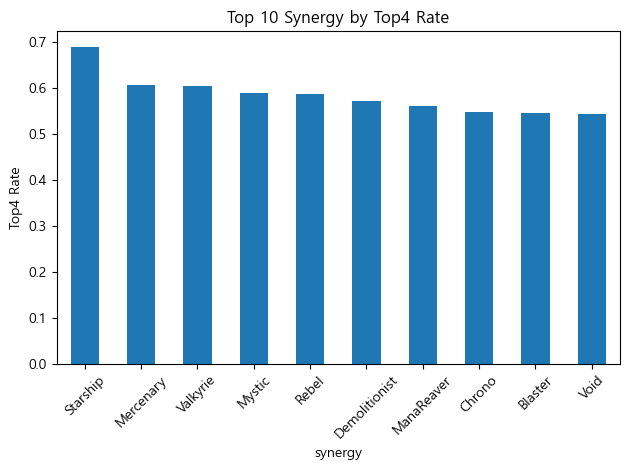

In [34]:
# top 10 시너지별 순방률 그래프
top_synergy = df_final.groupby('synergy')['top4_flag'].mean().sort_values(ascending=False).head(10)

plt.figure()
top_synergy.plot(kind='bar')
plt.title('Top 10 Synergy by Top4 Rate')
plt.ylabel('Top4 Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

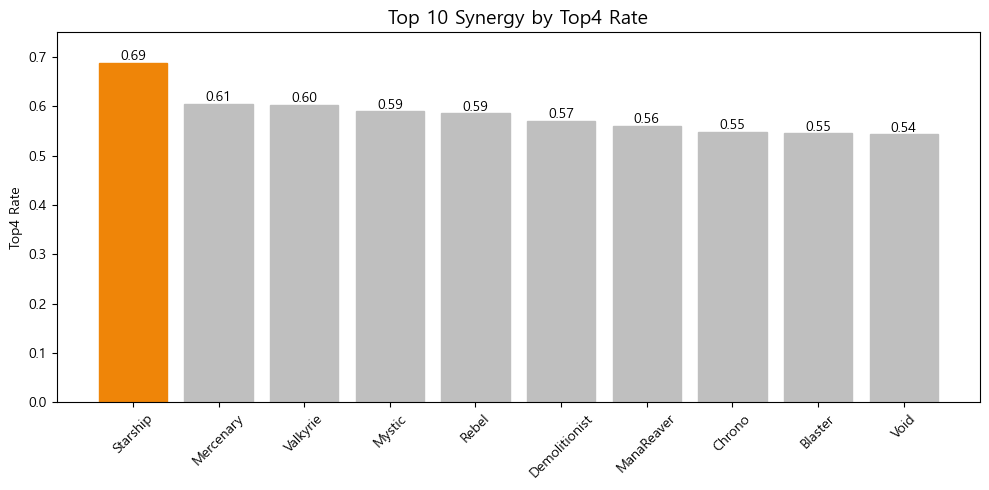

In [35]:
#미관보안
import matplotlib.pyplot as plt

top_synergy = df_final.groupby('synergy')['top4_flag'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

bars = plt.bar(top_synergy.index, top_synergy.values)

# 1등 강조 (주황색)
bars[0].set_color('#ef8508')

# 나머지 색 (연한 회색)
for i in range(1, len(bars)):
    bars[i].set_color('#bfbfbf')

plt.title('Top 10 Synergy by Top4 Rate', fontsize=14)
plt.ylabel('Top4 Rate')
plt.xticks(rotation=45)

# 값 표시
for i, v in enumerate(top_synergy.values):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.ylim(0, 0.75)

plt.tight_layout()
plt.show()

In [36]:
# ANOVA 검정
groups = [
    group['top4_flag'].astype(int).values
    for name, group in df_final.groupby('synergy')
]

f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA 결과")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6f}")

# 해석
print("\n해석")
if p_value < 0.05:
    print("시너지 간 순방률 차이는 통계적으로 유의미함 (귀무가설 기각)")
else:
    print("시너지 간 순방률 차이는 통계적으로 유의미하지 않음 (귀무가설 채택)")

ANOVA 결과
F-statistic: 406.8669
p-value: 0.000000

해석
시너지 간 순방률 차이는 통계적으로 유의미함 (귀무가설 기각)


---
## 2. 티어에 따라 순방률 차이가 존재하는가?

### 2-1.EDA

In [37]:
tier_stats = df_final.groupby('user_tier')['top4_flag'].mean().sort_values(ascending=False)
print(tier_stats)

user_tier
platinum        0.552160
diamond         0.548846
master          0.545221
grand_master    0.543642
challenger      0.543490
Name: top4_flag, dtype: float64


### 2-2. 시각화

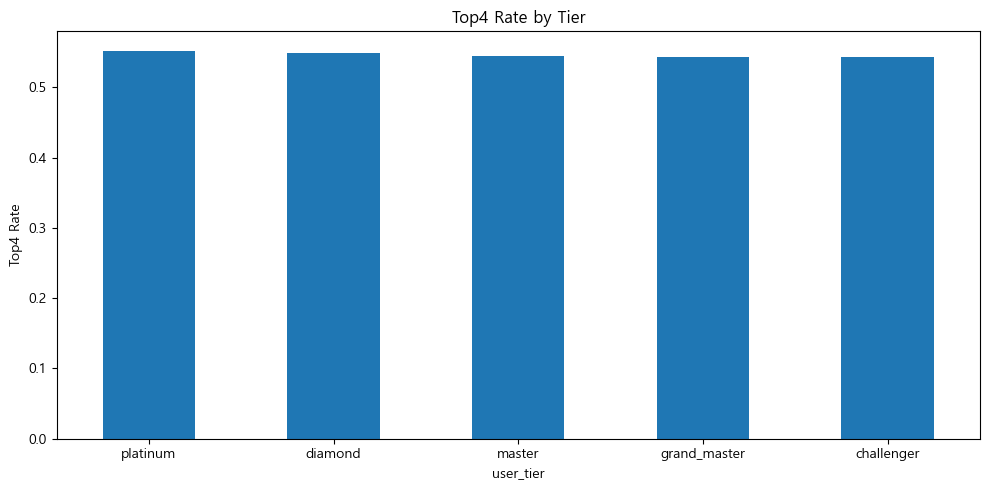

In [38]:
plt.figure(figsize=(10,5))
tier_stats.plot(kind='bar')

plt.title('Top4 Rate by Tier')
plt.ylabel('Top4 Rate')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

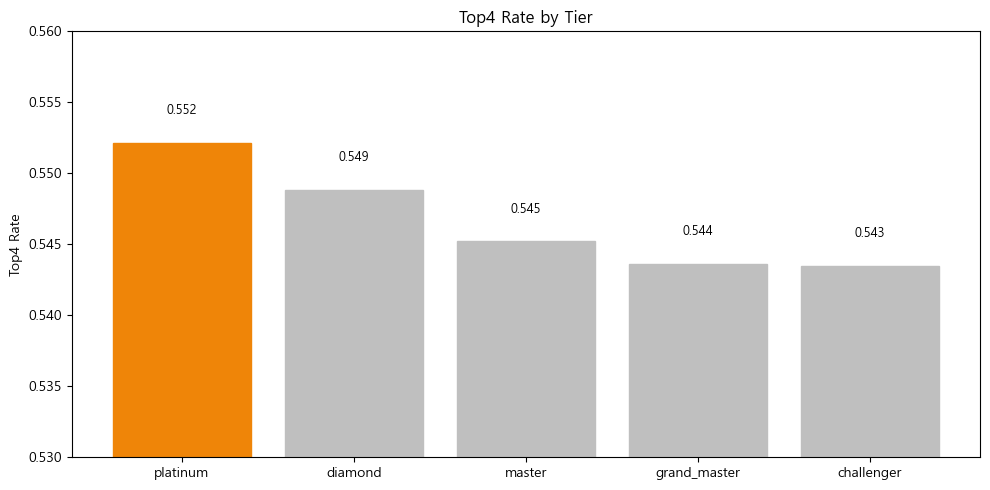

In [39]:
plt.figure(figsize=(10,5))

bars = plt.bar(tier_stats.index, tier_stats.values)

# 최고값 강조 (주황)
bars[0].set_color('#ef8508')

# 나머지 회색
for i in range(1, len(bars)):
    bars[i].set_color('#bfbfbf')

plt.title('Top4 Rate by Tier')
plt.ylabel('Top4 Rate')
plt.xticks(rotation=0)

# 값 표시
for i, v in enumerate(tier_stats.values):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center', fontsize=9)

plt.ylim(0.53, 0.56)  # 차이 강조

plt.tight_layout()
plt.show()

- 티어 간 차이가 작기 때문에 시각적으로 강조하기 위해 y축 범위를 조정

### 2-3. 통계검정(ANOVA)

In [40]:
groups = [
    group['top4_flag'].astype(int).values
    for name, group in df_final.groupby('user_tier')
]

f_stat, p_value = stats.f_oneway(*groups)

print("티어 ANOVA 결과")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("→ 티어가 높고 낮음에 따라 성과 차이가 있다고 볼 수 있음")
else:
    print("→ 티어에 따른 성과 차이는 크지 않다고 볼 수 있음")

티어 ANOVA 결과
p-value: 0.000000
→ 티어가 높고 낮음에 따라 성과 차이가 있다고 볼 수 있음


---
## 3. 픽률이 높은 시너지가 실제로도 효과적인가?

### 3-1. EDA

In [41]:
synergy_group = df_final.groupby('synergy').agg(
    pick_rate=('synergy', 'count'),
    top4_rate=('top4_flag', 'mean')
)

# 비율로 변환
synergy_group['pick_rate'] = synergy_group['pick_rate'] / synergy_group['pick_rate'].sum()

print(synergy_group.sort_values('pick_rate', ascending=False).head(10))

             pick_rate  top4_rate
synergy                          
Chrono        0.113043   0.548607
Celestial     0.077363   0.538247
Mercenary     0.071677   0.605626
Blaster       0.065140   0.545081
ManaReaver    0.063922   0.560546
Blademaster   0.058631   0.513547
Brawler       0.056986   0.532792
Sorcerer      0.055910   0.536631
Vanguard      0.045766   0.488986
Sniper        0.041199   0.530638


### 3-2. 시각화

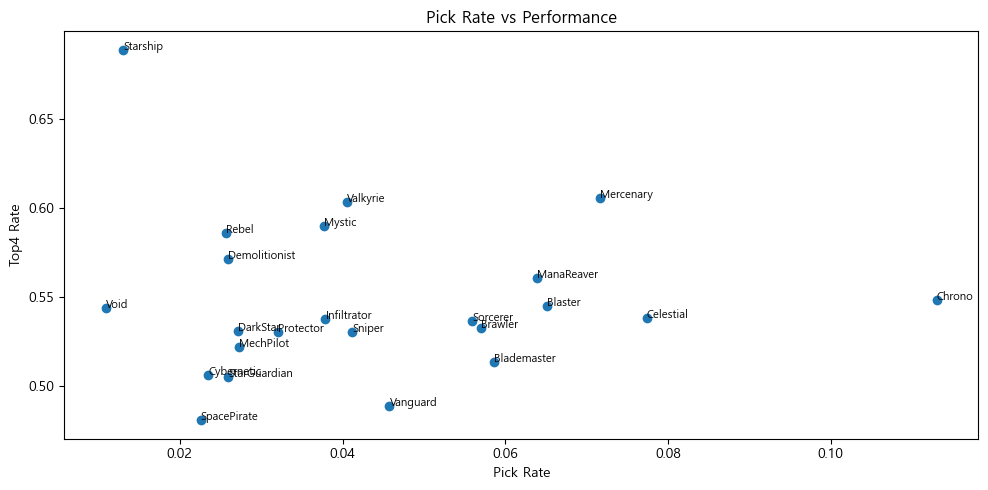

In [42]:
plt.figure(figsize=(10,5))

plt.scatter(synergy_group['pick_rate'], synergy_group['top4_rate'])

for i in synergy_group.index:
    plt.text(
        synergy_group.loc[i, 'pick_rate'],
        synergy_group.loc[i, 'top4_rate'],
        i,
        fontsize=8
    )

plt.xlabel('Pick Rate')
plt.ylabel('Top4 Rate')
plt.title('Pick Rate vs Performance')

plt.tight_layout()
plt.show()

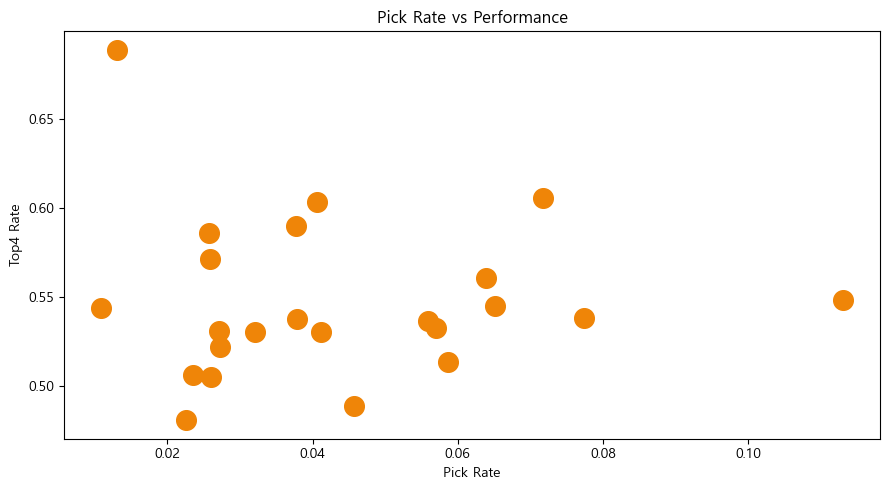

In [43]:
plt.figure(figsize=(9,5))

# 기본 점 (회색)
plt.scatter(
    synergy_group['pick_rate'],
    synergy_group['top4_rate'],
    color='#ef8508',
    s=200
)


plt.xlabel('Pick Rate')
plt.ylabel('Top4 Rate')
plt.title('Pick Rate vs Performance')

plt.tight_layout()
plt.show()

### 3-3. 통계검정(상관분석)

In [44]:
corr = synergy_group['pick_rate'].corr(synergy_group['top4_rate'])

print("상관계수:", round(corr, 3))

if abs(corr) > 0.3:
    print("→ 의미 있는 관계 존재")
else:
    print("→ 뚜렷한 관계 없음")

상관계수: -0.046
→ 뚜렷한 관계 없음
